In [25]:
# import the dataset
from tensorflow.keras.datasets import mnist

In [26]:
# call the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# the datasets under keras are already splitted into train and test samples

In [27]:
# shape of the training data
x_train.shape , y_train.shape

((60000, 28, 28), (60000,))

In [28]:
# shape of the testing data
x_test.shape , y_test.shape

((10000, 28, 28), (10000,))

In [29]:
# type of the data
x_train.dtype

dtype('uint8')

In [30]:
# what is the pixel value of the train data
x_train.min(), x_train.max()

(np.uint8(0), np.uint8(255))

In [31]:
# normalize the data
x_train = x_train / 255.0

# we can refer it as a type of scaling
x_test = x_test / 255.0

In [32]:
# verify
x_train.min(), x_train.max()

(np.float64(0.0), np.float64(1.0))

In [33]:
import numpy as np

In [34]:
# now we have to identify how many unique categories are there in the y_train

np.unique(y_train)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [35]:
# conversion into category, utlizing keras utility tool
from tensorflow.keras.utils import to_categorical

In [36]:
# conversions into category
y_train = to_categorical(y_train, 10)

# as neural networks follows a probabilistic approach

y_test = to_categorical(y_test, 10)

In [37]:
# verify
y_train[:1]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]])

In [38]:
# importing the dependencies
from tensorflow.keras.models import Sequential

In [39]:
# cnn specifications
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [40]:
# moode
model = Sequential()

In [41]:
# convolutional layer 1

model.add(Conv2D(32, (3 , 3), activation = "relu", padding = "same" , input_shape = (28 , 28 , 1)))

model.add(Conv2D(32, (3 , 3), activation = "relu", padding = "same"))

model.add(MaxPooling2D(2 ,2))

model.add(Dropout(0.25))


In [42]:
# convolutional layer 2

# we will increase the no. of neurons from 32 to 64

model.add(Conv2D(64, (3 , 3), activation = "relu", padding = "same"))

model.add(Conv2D(64, (3 , 3), activation = "relu", padding = "same"))

model.add(MaxPooling2D(2 ,2))

model.add(Dropout(0.25))

In [43]:
# dense layer

model.add(Flatten())

model.add(Dense(256, activation = "relu"))

model.add(Dropout(0.5))

model.add(Dense(10 , activation = "softmax"))


In [44]:
model.compile(optimizer = "adam",

                loss = "categorical_crossentropy",

                metrics = ["accuracy"])

In [45]:
history = model.fit(x_train, y_train,

                    epochs =10,
                     # Number of times the model will see the entire training dataset

                    batch_size = 64,
                    # Here the model processes 64 images at a time

                    validation_data = (x_test, y_test))
                    # Validation data used to evaluate the model after each epoch

Epoch 1/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 38s 38ms/step - accuracy: 0.9387 - loss: 0.1967 - val_accuracy: 0.9848 - val_loss: 0.0478
Epoch 2/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 44s 41ms/step - accuracy: 0.9801 - loss: 0.0658 - val_accuracy: 0.9832 - val_loss: 0.0495
Epoch 3/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 37s 39ms/step - accuracy: 0.9844 - loss: 0.0516 - val_accuracy: 0.9928 - val_loss: 0.0216
Epoch 4/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 35s 37ms/step - accuracy: 0.9866 - loss: 0.0426 - val_accuracy: 0.9942 - val_loss: 0.0201
Epoch 5/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 35s 38ms/step - accuracy: 0.9892 - loss: 0.0355 - val_accuracy: 0.9936 - val_loss: 0.0198
Epoch 6/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 35s 37ms/step - accuracy: 0.9903 - loss: 0.0309 - val_accuracy: 0.9944 - val_loss: 0.0198
Epoch 7/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - accuracy: 0.9915 - loss: 0.0286 - val_accuracy: 0.9950 - val_loss: 0.0154
Epoch 8/10
938/938 ━━━━━━━━━━━━━━━━━━━━ 35s 37ms/step - accuracy: 0.9919 - loss: 0.0246 - 

In [46]:
# import the matplotlib

import matplotlib.pyplot as plt
%matplotlib inline

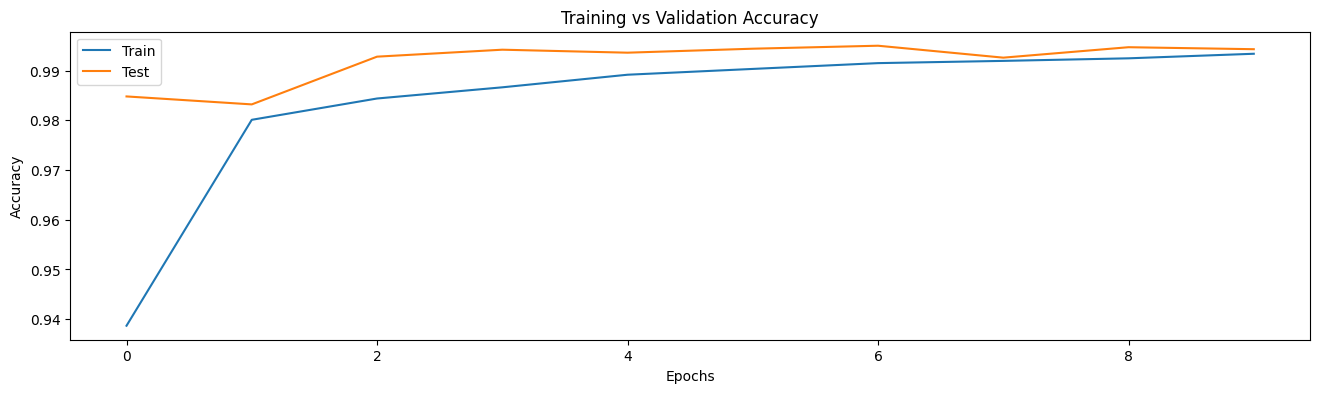

In [47]:
# accuracy graph
plt.figure(figsize = (16, 4))

plt.plot(history.history["accuracy"])

plt.plot(history.history["val_accuracy"])

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epochs")

plt.ylabel("Accuracy")

plt.legend(["Train" , "Test"])

plt.show()

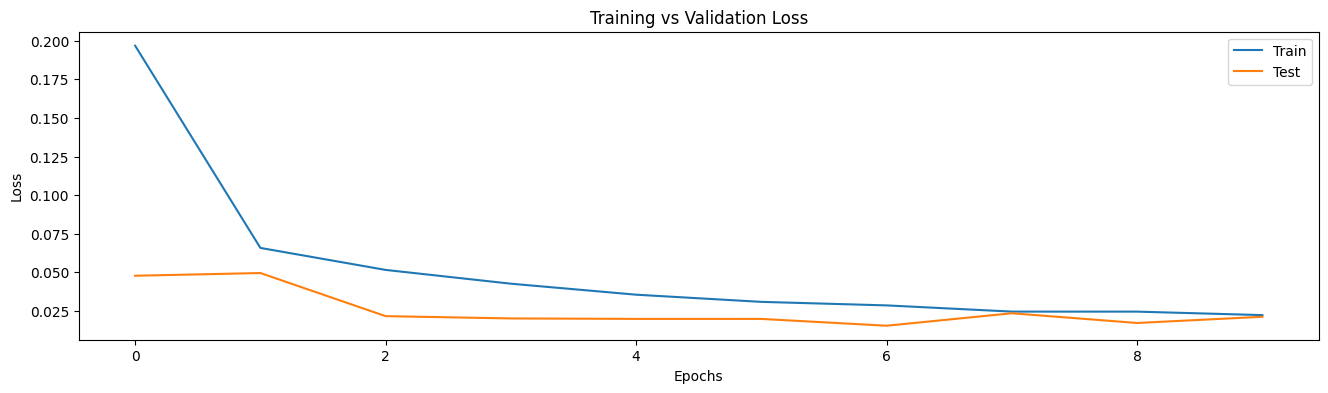

In [48]:
# loss graph
plt.figure(figsize = (16, 4))

plt.plot(history.history["loss"])

plt.plot(history.history["val_loss"])

plt.title("Training vs Validation Loss")

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.legend(["Train" , "Test"])

plt.show()

---

In [49]:
import numpy as np

In [50]:
class_names = [
    "0", "1", "2", "3", "4",
    "5", "6", "7", "8", "9"
]

In [52]:
pred = model.predict(x_test[:100])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


In [53]:
pred[:1]

array([[3.9876597e-17, 6.0658488e-13, 8.5393862e-12, 2.8680583e-14,
        3.8981563e-16, 8.3879668e-20, 1.7015114e-23, 1.0000000e+00,
        4.3458179e-18, 2.2111440e-12]], dtype=float32)

In [54]:
# selecting the max value
pred_classes = np.argmax(pred , axis = 1)

In [55]:
pred_classes[:10]

array([7, 2, 1, 0, 4, 1, 4, 9, 5, 9])

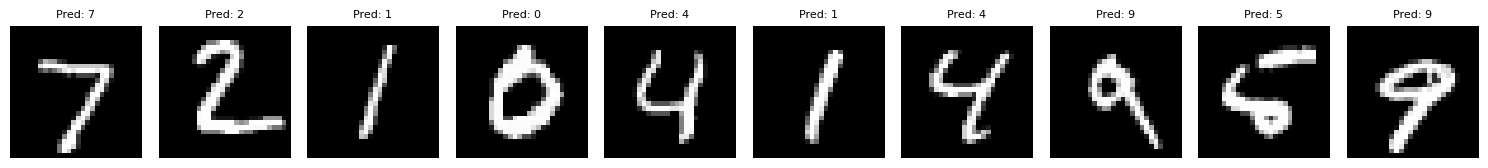

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plot 100 images (10x10 grid)
plt.figure(figsize=(15, 15))

for i in range(10):

    plt.subplot(10, 10, i + 1)

    plt.imshow(x_test[i], cmap="gray")

    plt.title(f"Pred: {class_names[pred_classes[i]]}", fontsize=8)

    plt.axis("off")

plt.tight_layout()

plt.show()

---

In [59]:
import joblib

In [60]:
# Save/Dump model
model.save("mnist_model.h5")